<a href="https://colab.research.google.com/github/votrananhkiet/Nhom6_COS201_IC2008_QAM/blob/main/QAM_Modulator_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# =========================
# Tao chuoi bit dau vao
# =========================

np.random.seed(1)   # de ket qua lap lai duoc

num_symbols = 100000
bits_per_symbol = 4
num_bits = num_symbols * bits_per_symbol

bits = np.random.randint(0, 2, num_bits)

print("So bit:", num_bits)
print("20 bit dau tien:")
print(bits[:20])


# =========================
# Tao input test giong Verilog
# bits_in chay tu 0 den 15
# Dung cho phan so sanh voi RTL waveform
# =========================

bits_in_test = np.arange(16)

print("bits_in_test giong Verilog:")
print(bits_in_test)

So bit: 400000
20 bit dau tien:
[1 1 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 1 0 0]
bits_in_test giong Verilog:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [3]:
# =========================
# Ham mapping 2 bit -> muc bien do
# Gray mapping:
# 00 -> -3
# 01 -> -1
# 11 -> +1
# 10 -> +3
# =========================

def bits_to_level(b1, b2):
    if b1 == 0 and b2 == 0:
        return -3
    elif b1 == 0 and b2 == 1:
        return -1
    elif b1 == 1 and b2 == 1:
        return 1
    elif b1 == 1 and b2 == 0:
        return 3
    else:
        return 0


# =========================
# Mapper 16-QAM giong Verilog
#
# bits_in[3:2] -> I
# bits_in[1:0] -> Q
#
# Scale giong Verilog:
# -3 -> -96
# -1 -> -32
# +1 -> +32
# +3 -> +96
# =========================

QAM_SCALE = 32

def qam_mapper_verilog_style(bits_in):
    b3 = (bits_in >> 3) & 1
    b2 = (bits_in >> 2) & 1
    b1 = (bits_in >> 1) & 1
    b0 = bits_in & 1

    I_level = bits_to_level(b3, b2)
    Q_level = bits_to_level(b1, b0)

    I_sym = I_level * QAM_SCALE
    Q_sym = Q_level * QAM_SCALE

    return I_sym, Q_sym

In [4]:
# =========================
# Mapping bit -> symbol 16-QAM
# Moi 4 bit tao thanh 1 symbol
#
# Quy uoc giong Verilog:
# bits_in[3:2] -> I
# bits_in[1:0] -> Q
#
# Gray mapping:
# 00 -> -3
# 01 -> -1
# 11 -> +1
# 10 -> +3
# =========================

# Chia chuoi bit thanh tung nhom 4 bit
bits_group = bits.reshape(-1, 4)

# Doi moi nhom 4 bit thanh bits_in 0..15
# [b3 b2 b1 b0] giong Verilog
bits_in_random = (
    bits_group[:, 0] * 8 +
    bits_group[:, 1] * 4 +
    bits_group[:, 2] * 2 +
    bits_group[:, 3]
)

I = []
Q = []

I_sym_verilog = []
Q_sym_verilog = []

for bits_in in bits_in_random:
    # Mapper co scale giong Verilog: -96, -32, 32, 96
    i_sym, q_sym = qam_mapper_verilog_style(int(bits_in))

    I_sym_verilog.append(i_sym)
    Q_sym_verilog.append(q_sym)

    # Doi nguoc ve muc -3, -1, 1, 3 de dung cho phan algorithm/constellation
    I.append(i_sym / QAM_SCALE)
    Q.append(q_sym / QAM_SCALE)

I = np.array(I)
Q = np.array(Q)

I_sym_verilog = np.array(I_sym_verilog)
Q_sym_verilog = np.array(Q_sym_verilog)

symbols = I + 1j * Q

print("So symbol:", len(symbols))
print("10 symbol dau tien:")
print(symbols[:10])

print("\n10 I_sym_verilog dau tien:")
print(I_sym_verilog[:10])

print("\n10 Q_sym_verilog dau tien:")
print(Q_sym_verilog[:10])

So symbol: 100000
10 symbol dau tien:
[ 1.-3.j  1.+1.j  3.-1.j -1.+3.j -1.-3.j -1.-3.j  3.-3.j  3.-3.j  1.+1.j
  3.-3.j]

10 I_sym_verilog dau tien:
[ 32  32  96 -32 -32 -32  96  96  32  96]

10 Q_sym_verilog dau tien:
[-96  32 -32  96 -96 -96 -96 -96  32 -96]


In [5]:
# =========================
# Chuan hoa cong suat trung binh ve 1
# Phan nay dung cho mo phong thuat toan:
# Constellation, BER, EVM
#
# Luu y:
# Trong Verilog RTL, ta KHONG dung symbols_norm.
# Verilog dung truc tiep fixed-point:
# -3 -> -96
# -1 -> -32
# +1 -> +32
# +3 -> +96
# =========================

avg_power = np.mean(np.abs(symbols) ** 2)
symbols_norm = symbols / np.sqrt(avg_power)

print("Cong suat trung binh truoc chuan hoa:", avg_power)
print("Cong suat trung binh sau chuan hoa:", np.mean(np.abs(symbols_norm) ** 2))

print("\nThong so fixed-point dung cho Verilog:")
print("QAM_SCALE =", QAM_SCALE)
print("I_sym_verilog unique:", np.unique(I_sym_verilog))
print("Q_sym_verilog unique:", np.unique(Q_sym_verilog))

Cong suat trung binh truoc chuan hoa: 9.993760000000002
Cong suat trung binh sau chuan hoa: 1.0000000000000002

Thong so fixed-point dung cho Verilog:
QAM_SCALE = 32
I_sym_verilog unique: [-96 -32  32  96]
Q_sym_verilog unique: [-96 -32  32  96]


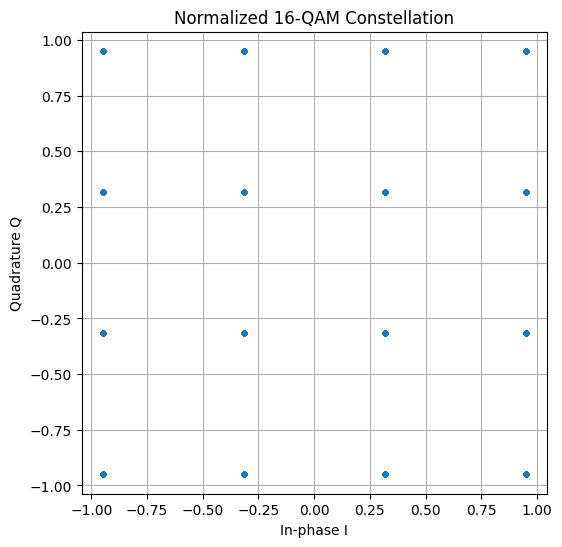

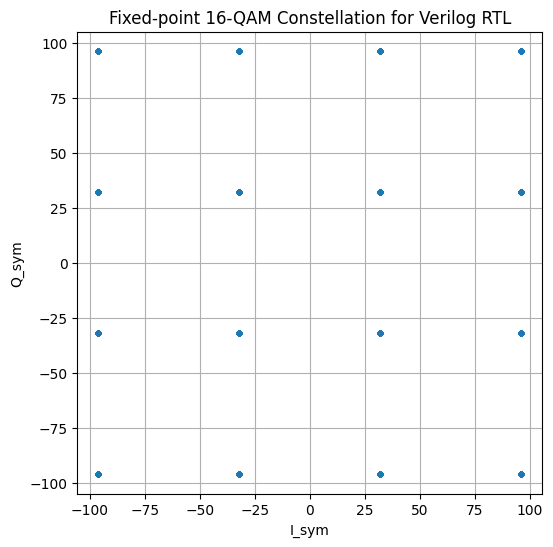

In [6]:
# =========================
# Ve chom sao 16-QAM
# =========================

# Hinh 1: constellation da chuan hoa cong suat ve 1
# Dung cho phan thuat toan BER/EVM
plt.figure(figsize=(6, 6))
plt.scatter(np.real(symbols_norm), np.imag(symbols_norm), s=10)
plt.title("Normalized 16-QAM Constellation")
plt.xlabel("In-phase I")
plt.ylabel("Quadrature Q")
plt.grid(True)
plt.axis("equal")
plt.savefig("normalized_16qam_constellation.png", dpi=300, bbox_inches="tight")
plt.show()


# Hinh 2: constellation fixed-point giong Verilog
# Verilog dung cac muc: -96, -32, +32, +96
plt.figure(figsize=(6, 6))
plt.scatter(I_sym_verilog, Q_sym_verilog, s=10)
plt.title("Fixed-point 16-QAM Constellation for Verilog RTL")
plt.xlabel("I_sym")
plt.ylabel("Q_sym")
plt.grid(True)
plt.axis("equal")
plt.savefig("fixed_point_16qam_constellation_verilog.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# =========================
# Demapper 16-QAM
# Dau vao: symbol da chuan hoa
# Dau ra: chuoi bit khoi phuc
#
# Cell nay dung cho phan Python algorithm:
# AWGN + BER
#
# Luu y:
# Verilog RTL cua project hien tai chi mo phong QAM Modulator,
# nen khong can viet demapper trong Verilog.
# =========================

def qam16_demapper(received_symbols, avg_power):
    levels = np.array([-3, -1, 1, 3])
    levels_norm = levels / np.sqrt(avg_power)

    recovered_bits = []

    for sym in received_symbols:
        i_rx = np.real(sym)
        q_rx = np.imag(sym)

        # Tim muc gan nhat tren truc I va truc Q
        i_index = np.argmin(np.abs(i_rx - levels_norm))
        q_index = np.argmin(np.abs(q_rx - levels_norm))

        i_level = levels[i_index]
        q_level = levels[q_index]

        # Doi muc bien do ve bit theo Gray mapping
        i_bits = level_to_bits(i_level)
        q_bits = level_to_bits(q_level)

        recovered_bits.extend(i_bits + q_bits)

    return np.array(recovered_bits)

In [8]:
# =========================
# Demapper 16-QAM
# Dau vao: symbol da chuan hoa
# Dau ra: chuoi bit khoi phuc
#
# Cell nay dung cho Python algorithm:
# AWGN + BER
# =========================

def qam16_demapper(received_symbols, avg_power):
    levels = np.array([-3, -1, 1, 3])
    levels_norm = levels / np.sqrt(avg_power)

    recovered_bits = []

    for sym in received_symbols:
        i_rx = np.real(sym)
        q_rx = np.imag(sym)

        # Tim muc gan nhat tren truc I va Q
        i_index = np.argmin(np.abs(i_rx - levels_norm))
        q_index = np.argmin(np.abs(q_rx - levels_norm))

        i_level = levels[i_index]
        q_level = levels[q_index]

        # Doi muc bien do ve bit theo Gray mapping
        if i_level == -3:
            i_bits = [0, 0]
        elif i_level == -1:
            i_bits = [0, 1]
        elif i_level == 1:
            i_bits = [1, 1]
        elif i_level == 3:
            i_bits = [1, 0]

        if q_level == -3:
            q_bits = [0, 0]
        elif q_level == -1:
            q_bits = [0, 1]
        elif q_level == 1:
            q_bits = [1, 1]
        elif q_level == 3:
            q_bits = [1, 0]

        recovered_bits.extend(i_bits + q_bits)

    return np.array(recovered_bits)

In [9]:
# =========================
# Kiem tra BER khi khong co nhieu
# =========================

recovered_bits = qam16_demapper(symbols_norm, avg_power)

recovered_bits = recovered_bits[:len(bits)]

num_error_bits = np.sum(bits != recovered_bits)
ber = num_error_bits / len(bits)

print("So bit loi:", num_error_bits)
print("Tong so bit:", len(bits))
print("BER khong co nhieu:", ber)

if ber == 0:
    print("Ket qua dung: Mapper va Demapper hoat dong chinh xac khi khong co nhieu.")
else:
    print("Can kiem tra lai mapper/demapper vi BER khong bang 0.")

So bit loi: 0
Tong so bit: 400000
BER khong co nhieu: 0.0
Ket qua dung: Mapper va Demapper hoat dong chinh xac khi khong co nhieu.


In [10]:
# =========================
# Ham them nhieu AWGN
#
# AWGN = Additive White Gaussian Noise
# Cell nay dung cho mo phong Python:
# QAM symbol -> them nhieu -> demapper -> BER
#
# Luu y:
# Verilog RTL hien tai chi lam QAM Modulator,
# nen AWGN khong nam trong Verilog.
# =========================

def add_awgn_noise(signal, snr_db):
    # Tinh cong suat trung binh cua tin hieu
    signal_power = np.mean(np.abs(signal) ** 2)

    # Doi SNR tu dB sang dang tuyen tinh
    snr_linear = 10 ** (snr_db / 10)

    # Tinh cong suat nhieu
    noise_power = signal_power / snr_linear

    # Nhieu phuc Gaussian:
    # chia 2 vi nhieu duoc chia deu cho phan thuc va phan ao
    noise = np.sqrt(noise_power / 2) * (
        np.random.randn(len(signal)) + 1j * np.random.randn(len(signal))
    )

    # Tin hieu nhan duoc sau khi them nhieu
    received_signal = signal + noise

    return received_signal

In [11]:
# =========================
# Them nhieu AWGN voi SNR = 10 dB
#
# Muc dich:
# Kiem tra BER cua 16-QAM khi co nhieu AWGN.
#
# Luu y:
# Cell nay dung cho Python algorithm.
# Verilog RTL hien tai chi lam QAM Modulator, khong them AWGN.
# =========================

snr_db = 10

# Them nhieu vao symbol da chuan hoa
received_symbols = add_awgn_noise(symbols_norm, snr_db)

# Demapper de khoi phuc bit
recovered_bits_noise = qam16_demapper(received_symbols, avg_power)

# Dam bao cung do dai voi chuoi bit goc
recovered_bits_noise = recovered_bits_noise[:len(bits)]

# Tinh so bit loi va BER
num_error_bits_noise = np.sum(bits != recovered_bits_noise)
ber_noise = num_error_bits_noise / len(bits)

print("SNR =", snr_db, "dB")
print("So bit loi:", num_error_bits_noise)
print("Tong so bit:", len(bits))
print("BER co nhieu:", ber_noise)

SNR = 10 dB
So bit loi: 23714
Tong so bit: 400000
BER co nhieu: 0.059285


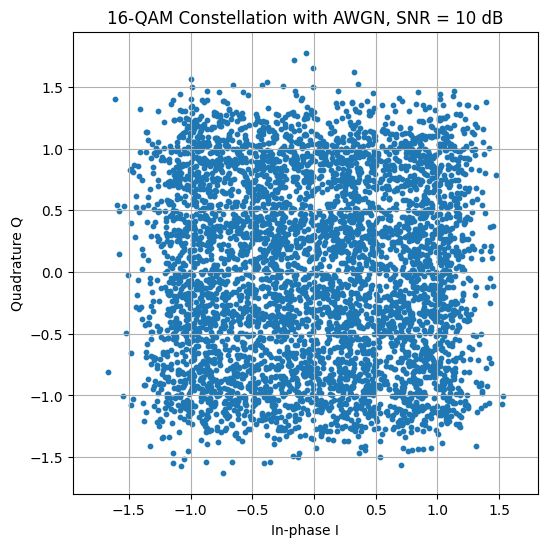

In [12]:
# =========================
# Ve chom sao sau khi them nhieu AWGN
#
# Muc dich:
# Quan sat anh huong cua nhieu AWGN len chom sao 16-QAM.
#
# Luu y:
# Cell nay dung cho Python algorithm.
# Verilog RTL hien tai chi lam QAM Modulator, khong mo phong AWGN.
# =========================

plt.figure(figsize=(6, 6))

# Chi ve mot phan symbol de hinh de nhin hon
num_plot = 5000

plt.scatter(
    np.real(received_symbols[:num_plot]),
    np.imag(received_symbols[:num_plot]),
    s=10
)

plt.title("16-QAM Constellation with AWGN, SNR = 10 dB")
plt.xlabel("In-phase I")
plt.ylabel("Quadrature Q")
plt.grid(True)
plt.axis("equal")

plt.savefig("qam_constellation_awgn_10db.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# =========================
# Tinh BER theo SNR
#
# Muc dich:
# Danh gia BER cua 16-QAM khi SNR thay doi.
#
# Luu y:
# Cell nay dung cho Python algorithm.
# Verilog RTL hien tai chi lam QAM Modulator,
# khong mo phong AWGN va BER.
# =========================

snr_db_values = np.arange(0, 31, 2)
ber_values = []

for snr_db in snr_db_values:
    # Them nhieu AWGN vao symbol da chuan hoa
    received_symbols_snr = add_awgn_noise(symbols_norm, snr_db)

    # Khoi phuc bit bang demapper
    recovered_bits_snr = qam16_demapper(received_symbols_snr, avg_power)

    # Dam bao cung do dai voi chuoi bit goc
    recovered_bits_snr = recovered_bits_snr[:len(bits)]

    # Tinh BER
    num_error_bits = np.sum(bits != recovered_bits_snr)
    ber = num_error_bits / len(bits)

    ber_values.append(ber)

    print("SNR =", snr_db, "dB, BER =", ber)

ber_values = np.array(ber_values)

SNR = 0 dB, BER = 0.286915
SNR = 2 dB, BER = 0.23763
SNR = 4 dB, BER = 0.1870475
SNR = 6 dB, BER = 0.1403425
SNR = 8 dB, BER = 0.0982475
SNR = 10 dB, BER = 0.059415
SNR = 12 dB, BER = 0.0278675
SNR = 14 dB, BER = 0.0092475
SNR = 16 dB, BER = 0.0018675
SNR = 18 dB, BER = 0.000135
SNR = 20 dB, BER = 7.5e-06
SNR = 22 dB, BER = 0.0
SNR = 24 dB, BER = 0.0
SNR = 26 dB, BER = 0.0
SNR = 28 dB, BER = 0.0
SNR = 30 dB, BER = 0.0


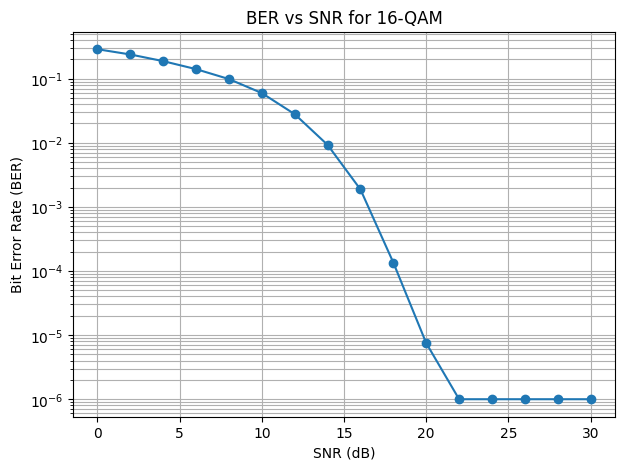

In [14]:
# =========================
# Ve do thi BER theo SNR
#
# Luu y:
# semilogy khong ve duoc BER = 0,
# nen ta thay gia tri 0 bang mot gia tri rat nho chi de ve hinh.
# Gia tri BER goc van giu nguyen trong ber_values.
# =========================

ber_plot = np.array(ber_values, dtype=float)

# Neu BER = 0 thi thay bang 1e-6 de ve tren thang log
ber_plot[ber_plot == 0] = 1e-6

plt.figure(figsize=(7, 5))
plt.semilogy(snr_db_values, ber_plot, marker='o')
plt.title("BER vs SNR for 16-QAM")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which="both")

plt.savefig("ber_vs_snr_16qam.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# =========================
# Ham gia lap fixed-point quantization
#
# Muc dich:
# Gia lap anh huong cua do dai tu fixed-point
# len tin hieu 16-QAM da chuan hoa.
#
# Cell nay dung cho phan:
# EVM vs Fixed-point Word Length
#
# Luu y:
# Verilog RTL cua minh dung integer fixed-point:
# -3 -> -96
# -1 -> -32
# +1 -> +32
# +3 -> +96
#
# Con ham nay dung cho tin hieu da chuan hoa gan [-1, 1].
# =========================

def quantize_fixed(x, word_length):
    """
    Gia lap fixed-point signed Q1.(word_length-1)

    x: tin hieu dau vao, thuong nam trong khoang [-1, 1]
    word_length: tong so bit fixed-point
    """

    max_int = 2**(word_length - 1) - 1
    min_int = -2**(word_length - 1)

    # Doi so thuc sang so nguyen fixed-point
    x_scaled = np.round(x * max_int)

    # Gioi han de tranh tran so
    x_clipped = np.clip(x_scaled, min_int, max_int)

    # Doi nguoc ve dang so thuc de tinh sai so/EVM
    x_quantized = x_clipped / max_int

    return x_quantized

In [16]:
# =========================
# Thu fixed-point voi 8-bit, 12-bit, 16-bit
#
# Muc dich:
# So sanh symbol ly tuong voi symbol sau khi bi quantization.
#
# Cell nay dung cho phan:
# Fixed-point precision effects
#
# Luu y:
# Day la mo phong fixed-point tren symbol da chuan hoa.
# Verilog RTL dung fixed-point integer rieng:
# -96, -32, +32, +96
# =========================

symbols_8bit = (
    quantize_fixed(np.real(symbols_norm), 8)
    + 1j * quantize_fixed(np.imag(symbols_norm), 8)
)

symbols_12bit = (
    quantize_fixed(np.real(symbols_norm), 12)
    + 1j * quantize_fixed(np.imag(symbols_norm), 12)
)

symbols_16bit = (
    quantize_fixed(np.real(symbols_norm), 16)
    + 1j * quantize_fixed(np.imag(symbols_norm), 16)
)

print("Symbol ly tuong dau tien:")
print(symbols_norm[:5])

print("\nSymbol 8-bit dau tien:")
print(symbols_8bit[:5])

print("\nSymbol 12-bit dau tien:")
print(symbols_12bit[:5])

print("\nSymbol 16-bit dau tien:")
print(symbols_16bit[:5])


# =========================
# Tinh EVM nhanh de so sanh sai so
# =========================

def calculate_evm(test_signal, ideal_signal):
    error = test_signal - ideal_signal
    evm = np.sqrt(
        np.mean(np.abs(error) ** 2)
        / np.mean(np.abs(ideal_signal) ** 2)
    )
    return evm

evm_8bit = calculate_evm(symbols_8bit, symbols_norm)
evm_12bit = calculate_evm(symbols_12bit, symbols_norm)
evm_16bit = calculate_evm(symbols_16bit, symbols_norm)

print("\nEVM 8-bit :", evm_8bit)
print("EVM 12-bit:", evm_12bit)
print("EVM 16-bit:", evm_16bit)

Symbol ly tuong dau tien:
[ 0.31632648-0.94897943j  0.31632648+0.31632648j  0.94897943-0.31632648j
 -0.31632648+0.94897943j -0.31632648-0.94897943j]

Symbol 8-bit dau tien:
[ 0.31496063-0.95275591j  0.31496063+0.31496063j  0.95275591-0.31496063j
 -0.31496063+0.95275591j -0.31496063-0.95275591j]

Symbol 12-bit dau tien:
[ 0.31656082-0.94919394j  0.31656082+0.31656082j  0.94919394-0.31656082j
 -0.31656082+0.94919394j -0.31656082-0.94919394j]

Symbol 16-bit dau tien:
[ 0.31632435-0.94897305j  0.31632435+0.31632435j  0.94897305-0.31632435j
 -0.31632435+0.94897305j -0.31632435-0.94897305j]

EVM 8-bit : 0.004014680959322376
EVM 12-bit: 0.00031771380627926705
EVM 16-bit: 6.716350440284662e-06


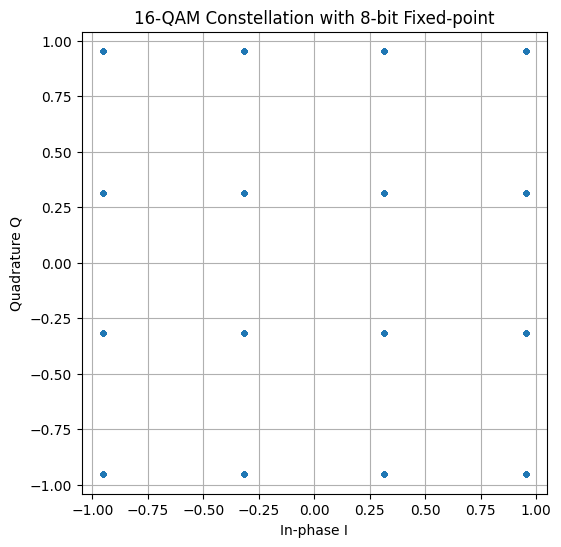

In [17]:
# =========================
# Ve chom sao sau fixed-point 8-bit
#
# Muc dich:
# Quan sat anh huong cua quantization 8-bit
# len chom sao 16-QAM da chuan hoa.
#
# Cell nay dung cho phan:
# Fixed-point precision effects
# =========================

plt.figure(figsize=(6, 6))

# Chi ve mot phan symbol de hinh de nhin va chay nhe hon
num_plot = 5000

plt.scatter(
    np.real(symbols_8bit[:num_plot]),
    np.imag(symbols_8bit[:num_plot]),
    s=10
)

plt.title("16-QAM Constellation with 8-bit Fixed-point")
plt.xlabel("In-phase I")
plt.ylabel("Quadrature Q")
plt.grid(True)
plt.axis("equal")

plt.savefig("qam_constellation_8bit_fixed_point.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# =========================
# BER theo do dai tu fixed-point
#
# Muc dich:
# Kiem tra anh huong cua word length fixed-point
# den BER cua he thong 16-QAM khi co AWGN.
#
# Luu y:
# Cell nay dung cho Python algorithm.
# Verilog RTL dung fixed-point integer rieng de mo phong modulator.
# =========================

word_lengths = [8, 10, 12, 14, 16]
snr_test = 12
num_trials = 20

ber_fixed_values = []

for wl in word_lengths:
    ber_trials = []

    # Luong tu hoa symbol theo word length hien tai
    # Chi can lam 1 lan cho moi word length
    symbols_fixed = (
        quantize_fixed(np.real(symbols_norm), wl)
        + 1j * quantize_fixed(np.imag(symbols_norm), wl)
    )

    for trial in range(num_trials):
        # Them nhieu AWGN
        received_fixed = add_awgn_noise(symbols_fixed, snr_test)

        # Demap de khoi phuc bit
        recovered_bits_fixed = qam16_demapper(received_fixed, avg_power)

        # Dam bao recovered_bits_fixed co cung do dai voi bits
        recovered_bits_fixed = recovered_bits_fixed[:len(bits)]

        # Tinh BER
        num_error_bits_fixed = np.sum(bits != recovered_bits_fixed)
        ber_fixed = num_error_bits_fixed / len(bits)

        ber_trials.append(ber_fixed)

    ber_avg = np.mean(ber_trials)
    ber_fixed_values.append(ber_avg)

    print("Word length =", wl, "bit, Average BER =", ber_avg)

ber_fixed_values = np.array(ber_fixed_values)

Word length = 8 bit, Average BER = 0.027937499999999997
Word length = 10 bit, Average BER = 0.028124750000000004
Word length = 12 bit, Average BER = 0.028103249999999996
Word length = 14 bit, Average BER = 0.027993125
Word length = 16 bit, Average BER = 0.028109375


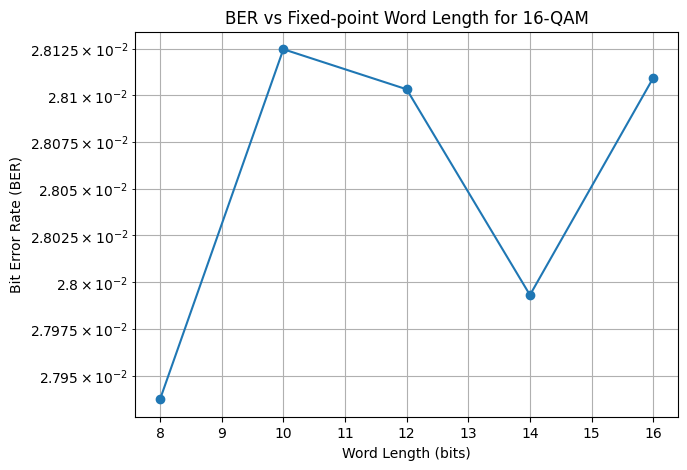

In [19]:
# =========================
# Ve BER theo word length
#
# Muc dich:
# Quan sat anh huong cua fixed-point word length
# den BER cua he thong 16-QAM.
#
# Luu y:
# Neu BER = 0, semilogy se khong ve duoc tren truc log.
# Nen ta thay BER = 0 bang gia tri nho de ve hinh.
# =========================

ber_fixed_plot = np.array(ber_fixed_values, dtype=float)

# Neu co BER = 0 thi thay bang 1e-6 chi de ve tren truc log
ber_fixed_plot[ber_fixed_plot == 0] = 1e-6

plt.figure(figsize=(7, 5))
plt.semilogy(word_lengths, ber_fixed_plot, marker='o')
plt.title("BER vs Fixed-point Word Length for 16-QAM")
plt.xlabel("Word Length (bits)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which="both")

plt.savefig("ber_vs_fixed_point_word_length.png", dpi=300, bbox_inches="tight")
plt.show()

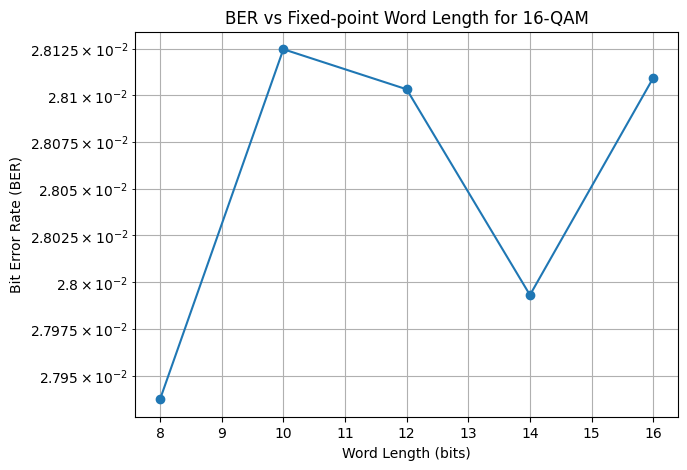

In [20]:
# =========================
# Ve BER theo word length
# =========================

ber_fixed_plot = np.array(ber_fixed_values, dtype=float)

# Neu BER = 0 thi thay bang gia tri nho chi de ve tren truc log
# Gia tri goc ber_fixed_values van giu nguyen
ber_fixed_plot[ber_fixed_plot == 0] = 1e-6

plt.figure(figsize=(7, 5))
plt.semilogy(word_lengths, ber_fixed_plot, marker='o')
plt.title("BER vs Fixed-point Word Length for 16-QAM")
plt.xlabel("Word Length (bits)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which="both")

plt.savefig("ber_vs_fixed_point_word_length.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# =========================
# Tinh EVM theo do dai tu fixed-point
#
# Muc dich:
# Danh gia anh huong cua word length fixed-point
# den sai so tin hieu 16-QAM.
#
# EVM cang nho thi tin hieu sau quantization
# cang gan voi tin hieu ly tuong.
# =========================

word_lengths_evm = [3, 4, 5, 6, 8, 10, 12, 14, 16]

evm_values = []

for wl in word_lengths_evm:
    # Luong tu hoa rieng phan I va Q
    symbols_fixed = (
        quantize_fixed(np.real(symbols_norm), wl)
        + 1j * quantize_fixed(np.imag(symbols_norm), wl)
    )

    # Tinh sai so giua fixed-point symbol va ideal symbol
    error = symbols_fixed - symbols_norm

    # Tinh EVM
    evm = np.sqrt(
        np.mean(np.abs(error) ** 2)
        / np.mean(np.abs(symbols_norm) ** 2)
    )

    evm_values.append(evm)

    print("Word length =", wl, "bit, EVM =", evm)

evm_values = np.array(evm_values)

Word length = 3 bit, EVM = 0.05376362519199623
Word length = 4 bit, EVM = 0.05948870198329263
Word length = 5 bit, EVM = 0.023109913223810858
Word length = 6 bit, EVM = 0.014870544378335947
Word length = 8 bit, EVM = 0.004014680959322376
Word length = 10 bit, EVM = 0.0007130942018189198
Word length = 12 bit, EVM = 0.00031771380627926705
Word length = 14 bit, EVM = 1.1639773240533453e-05
Word length = 16 bit, EVM = 6.716350440284662e-06


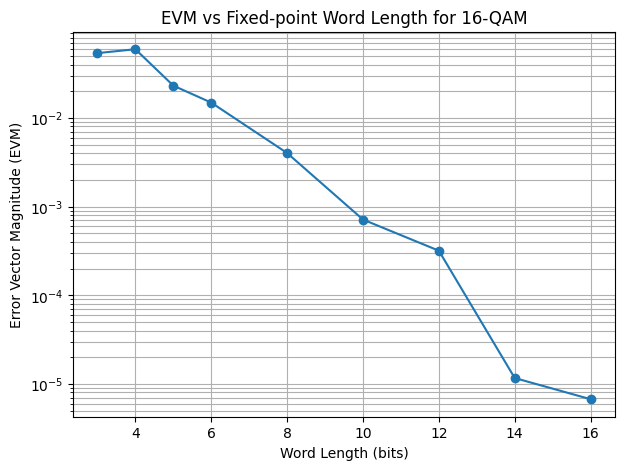

In [22]:
# =========================
# Ve EVM theo word length
#
# Muc dich:
# Quan sat anh huong cua fixed-point word length
# den sai so EVM cua 16-QAM.
#
# Word length cang lon -> sai so quantization cang nho -> EVM cang giam.
# =========================

evm_plot = np.array(evm_values, dtype=float)

# Neu EVM = 0 thi thay bang gia tri nho de ve tren truc log
evm_plot[evm_plot == 0] = 1e-8

plt.figure(figsize=(7, 5))
plt.semilogy(word_lengths_evm, evm_plot, marker='o')
plt.title("EVM vs Fixed-point Word Length for 16-QAM")
plt.xlabel("Word Length (bits)")
plt.ylabel("Error Vector Magnitude (EVM)")
plt.grid(True, which="both")

plt.savefig("evm_vs_fixed_point_word_length.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# =========================
# LUT-based sin/cos generator
#
# Co 2 kieu LUT:
#
# 1. lut_sincos_from_phase():
#    - Dung cho mo phong thuat toan tong quat
#    - Phase tinh bang radian
#    - Co the thay doi phase_bits, data_bits
#
# 2. nco_lut_verilog_style():
#    - Dung de khop voi Verilog RTL
#    - phase_addr = 0..15
#    - cos/sin scale = 127
# =========================


# =========================
# LUT tong quat cho phan algorithm
# =========================

def lut_sincos_from_phase(phase, phase_bits=4, data_bits=8):
    """
    phase: mang goc, don vi radian
    phase_bits: so bit dia chi LUT
    data_bits: so bit fixed-point cua gia tri sin/cos

    Ham nay dung cho phan:
    LUT carrier EVM vs Phase Width
    """

    lut_size = 2 ** phase_bits

    # Tao bang tra sin/cos
    k = np.arange(lut_size)
    phase_table = 2 * np.pi * k / lut_size

    sin_table = np.sin(phase_table)
    cos_table = np.cos(phase_table)

    # Luong tu hoa gia tri sin/cos
    sin_table_q = quantize_fixed(sin_table, data_bits)
    cos_table_q = quantize_fixed(cos_table, data_bits)

    # Doi phase radian thanh dia chi LUT
    phase_mod = np.mod(phase, 2 * np.pi)
    address = np.floor(phase_mod / (2 * np.pi) * lut_size).astype(int)
    address = np.clip(address, 0, lut_size - 1)

    sin_out = sin_table_q[address]
    cos_out = cos_table_q[address]

    return cos_out, sin_out


# =========================
# LUT NCO giong Verilog RTL
#
# Verilog:
# phase_addr: 4 bit
# LUT size: 16 mau / 1 chu ky
# cos/sin scale: 127
# =========================

cos_lut_verilog = np.array([
     127,  117,   90,   49,
       0,  -49,  -90, -117,
    -127, -117,  -90,  -49,
       0,   49,   90,  117
], dtype=int)

sin_lut_verilog = np.array([
       0,   49,   90,  117,
     127,  117,   90,   49,
       0,  -49,  -90, -117,
    -127, -117,  -90,  -49
], dtype=int)


def nco_lut_verilog_style(phase_addr):
    """
    phase_addr: dia chi pha 0..15
    return: cos_val, sin_val giong Verilog RTL
    """

    phase_addr = int(phase_addr) & 0xF

    cos_val = int(cos_lut_verilog[phase_addr])
    sin_val = int(sin_lut_verilog[phase_addr])

    return cos_val, sin_val


# =========================
# Kiem tra nhanh LUT giong Verilog
# =========================

lut_verilog_table = pd.DataFrame({
    "phase_addr": np.arange(16),
    "cos_val": cos_lut_verilog,
    "sin_val": sin_lut_verilog
})

display(lut_verilog_table)

,phase_addr,cos_val,sin_val
0,0,127,0
1,1,117,49
2,2,90,90
3,3,49,117
4,4,0,127
5,5,-49,117
6,6,-90,90
7,7,-117,49
8,8,-127,0
9,9,-117,-49


In [24]:
# =========================
# Tao song mang sin/cos de test LUT
# =========================

N = 2048
carrier_cycles = 13

n = np.arange(N)
phase = 2 * np.pi * carrier_cycles * n / N

cos_ideal = np.cos(phase)
sin_ideal = np.sin(phase)

cos_lut, sin_lut = lut_sincos_from_phase(
    phase,
    phase_bits=4,
    data_bits=8
)

print("5 gia tri cos ideal dau tien:")
print(cos_ideal[:5])

print("\n5 gia tri cos LUT dau tien:")
print(cos_lut[:5])

5 gia tri cos ideal dau tien:
[1.         0.99920476 0.9968203  0.99285041 0.98730142]

5 gia tri cos LUT dau tien:
[1. 1. 1. 1. 1.]


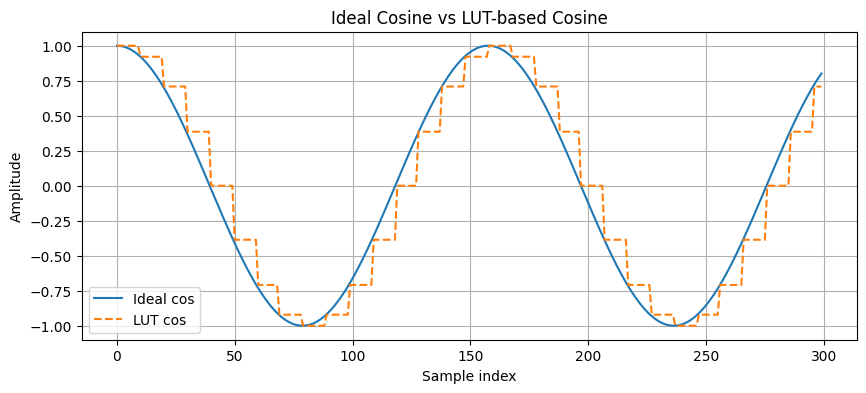

In [25]:
# =========================
# Ve so sanh cos ideal va cos LUT
#
# Muc dich:
# So sanh song mang cosine ly tuong voi cosine tao bang LUT.
#
# Cell nay dung cho phan LUT-based carrier generator
# trong Python algorithm.
# =========================

plt.figure(figsize=(10, 4))

plt.plot(cos_ideal[:300], label="Ideal cos")
plt.plot(cos_lut[:300], "--", label="LUT cos")

plt.title("Ideal Cosine vs LUT-based Cosine")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.savefig("ideal_cos_vs_lut_cos.png", dpi=300, bbox_inches="tight")
plt.show()

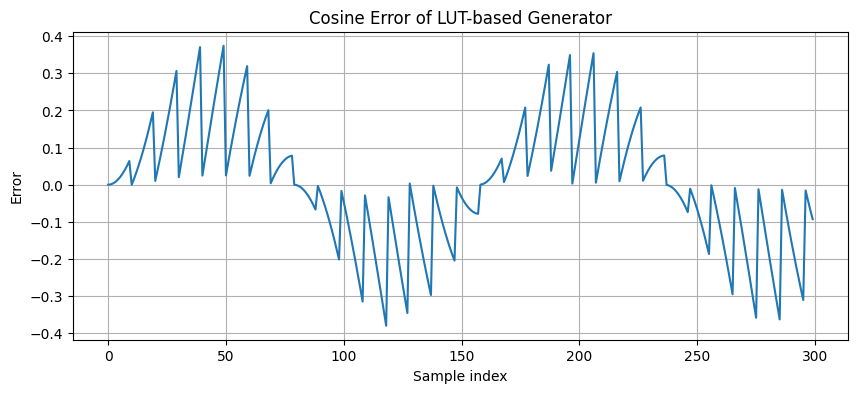

LUT carrier EVM = 0.22455004856307928


In [26]:
# =========================
# Sai so LUT so voi ideal
#
# Muc dich:
# Danh gia sai so cua LUT-based sin/cos generator
# so voi sin/cos ly tuong.
#
# Cell nay dung cho phan:
# LUT-based carrier accuracy
# =========================

# Sai so giua LUT va ideal
cos_error = cos_lut - cos_ideal
sin_error = sin_lut - sin_ideal

# Ve sai so cosine
plt.figure(figsize=(10, 4))
plt.plot(cos_error[:300])
plt.title("Cosine Error of LUT-based Generator")
plt.xlabel("Sample index")
plt.ylabel("Error")
plt.grid(True)

plt.savefig("lut_cosine_error.png", dpi=300, bbox_inches="tight")
plt.show()

# Tinh EVM cua carrier LUT
lut_evm = np.sqrt(
    np.mean(cos_error**2 + sin_error**2)
    / np.mean(cos_ideal**2 + sin_ideal**2)
)

print("LUT carrier EVM =", lut_evm)

In [27]:
# =========================
# LUT EVM theo phase width
#
# Muc dich:
# Danh gia anh huong cua so bit dia chi LUT
# den do chinh xac cua bo tao song mang sin/cos.
#
# phase_bits cang lon -> LUT size cang lon -> sai so pha cang nho
# =========================

phase_bits_list = [4, 5, 6, 7, 8, 10, 12]

# Giu data_bits = 12 de tap trung danh gia sai so do phase width
data_bits_lut = 12

lut_evm_phase = []
lut_size_list = []

for pb in phase_bits_list:
    # Tao sin/cos bang LUT voi phase width hien tai
    cos_lut_tmp, sin_lut_tmp = lut_sincos_from_phase(
        phase,
        phase_bits=pb,
        data_bits=data_bits_lut
    )

    # Tinh sai so so voi sin/cos ly tuong
    err_cos = cos_lut_tmp - cos_ideal
    err_sin = sin_lut_tmp - sin_ideal

    # Tinh EVM cua carrier
    evm = np.sqrt(
        np.mean(err_cos**2 + err_sin**2)
        / np.mean(cos_ideal**2 + sin_ideal**2)
    )

    lut_size = 2 ** pb

    lut_evm_phase.append(evm)
    lut_size_list.append(lut_size)

    print(
        "Phase bits =", pb,
        "| LUT size =", lut_size,
        "| EVM =", evm
    )

lut_evm_phase = np.array(lut_evm_phase)
lut_size_list = np.array(lut_size_list)


# =========================
# Tao bang ket qua
# =========================

lut_phase_table = pd.DataFrame({
    "Phase bits": phase_bits_list,
    "LUT size": lut_size_list,
    "LUT carrier EVM": lut_evm_phase
})

display(lut_phase_table)

Phase bits = 4 | LUT size = 16 | EVM = 0.224518459550251
Phase bits = 5 | LUT size = 32 | EVM = 0.11192352293833921
Phase bits = 6 | LUT size = 64 | EVM = 0.05533705427488156
Phase bits = 7 | LUT size = 128 | EVM = 0.027029277836213
Phase bits = 8 | LUT size = 256 | EVM = 0.012870424223730852
Phase bits = 10 | LUT size = 1024 | EVM = 0.002228497830766267
Phase bits = 12 | LUT size = 4096 | EVM = 0.0002624794318503736


,Phase bits,LUT size,LUT carrier EVM
0,4,16,0.224518
1,5,32,0.111924
2,6,64,0.055337
3,7,128,0.027029
4,8,256,0.012870
5,10,1024,0.002228
6,12,4096,0.000262


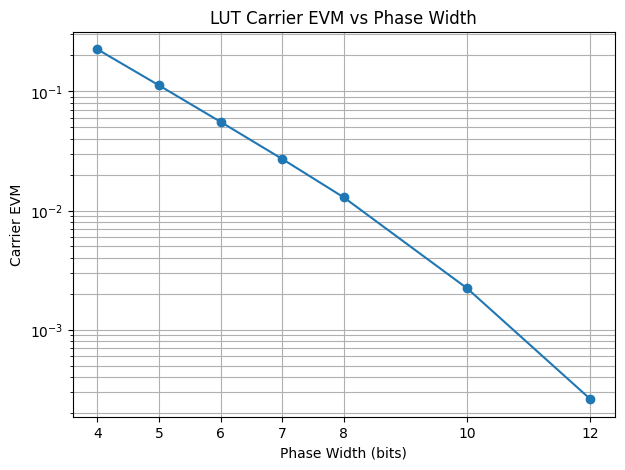

In [28]:
# =========================
# Ve LUT EVM theo phase width
#
# Muc dich:
# Quan sat anh huong cua phase width den sai so LUT carrier.
#
# phase width cang lon -> LUT size cang lon
# -> do phan giai pha tot hon
# -> carrier EVM giam
# =========================

lut_evm_plot = np.array(lut_evm_phase, dtype=float)

# Neu EVM = 0 thi thay bang gia tri nho de ve tren truc log
lut_evm_plot[lut_evm_plot == 0] = 1e-12

plt.figure(figsize=(7, 5))
plt.semilogy(phase_bits_list, lut_evm_plot, marker='o')

plt.title("LUT Carrier EVM vs Phase Width")
plt.xlabel("Phase Width (bits)")
plt.ylabel("Carrier EVM")
plt.xticks(phase_bits_list)
plt.grid(True, which="both")

plt.savefig("lut_evm_vs_phase_width.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# =========================
# Uoc luong bo nho LUT
#
# Muc dich:
# Danh gia tai nguyen bo nho can dung cho LUT sin/cos.
#
# Cong thuc:
# Memory bits = LUT entries x data bits x 2
#
# Nhan 2 vi ta luu ca sin va cos.
# =========================

lut_memory_rows = []

for pb in phase_bits_list:
    lut_entries = 2 ** pb

    # Luu ca sin va cos, moi gia tri data_bits_lut bit
    memory_bits = lut_entries * data_bits_lut * 2
    memory_bytes = memory_bits / 8
    memory_kbytes = memory_bytes / 1024

    lut_memory_rows.append({
        "Phase bits": pb,
        "LUT entries": lut_entries,
        "Data bits": data_bits_lut,
        "Memory bits": memory_bits,
        "Memory bytes": memory_bytes,
        "Memory KB": memory_kbytes
    })

lut_memory_table = pd.DataFrame(lut_memory_rows)

display(lut_memory_table)

,Phase bits,LUT entries,Data bits,Memory bits,Memory bytes,Memory KB
0,4,16,12,384,48.0,0.046875
1,5,32,12,768,96.0,0.093750
2,6,64,12,1536,192.0,0.187500
3,7,128,12,3072,384.0,0.375000
4,8,256,12,6144,768.0,0.750000
5,10,1024,12,24576,3072.0,3.000000
6,12,4096,12,98304,12288.0,12.000000


In [30]:
# =========================
# Ham quantize cho gia tri co khoang [-max_abs, +max_abs]
#
# Muc dich:
# Gia lap fixed-point quantization cho CORDIC.
#
# Dung cho:
# x, y  -> max_abs = 1.0
# z     -> max_abs = np.pi
#
# Cell nay dung cho phan:
# CORDIC-based carrier generator trong Python algorithm.
# =========================

def quantize_signed_range(x, word_length, max_abs=1.0):
    """
    Quantize gia tri x trong khoang [-max_abs, +max_abs]
    sang fixed-point signed voi word_length bit.

    x: gia tri dau vao, co the la so hoac numpy array
    word_length: so bit fixed-point
    max_abs: bien do lon nhat cua khoang can quantize
    """

    if max_abs == 0:
        raise ValueError("max_abs phai khac 0")

    max_int = 2**(word_length - 1) - 1
    min_int = -2**(word_length - 1)

    # Doi tu gia tri thuc sang so nguyen fixed-point
    x_scaled = np.round(x / max_abs * max_int)

    # Gioi han de tranh tran so
    x_clipped = np.clip(x_scaled, min_int, max_int)

    # Doi nguoc ve gia tri thuc sau quantization
    x_quantized = x_clipped / max_int * max_abs

    return x_quantized

In [31]:
# =========================
# CORDIC-based sin/cos generator
#
# Muc dich:
# Tao sin/cos bang thuat toan CORDIC.
#
# CORDIC khong dung LUT sin/cos day du,
# ma tinh bang cac phep cong/tru va dich bit.
#
# Cell nay dung cho phan:
# CORDIC-based carrier generator trong Python algorithm.
# =========================

def cordic_sincos_from_phase(phase, iterations=12, word_length=16):
    """
    phase: mang goc, don vi radian
    iterations: so vong lap CORDIC
    word_length: so bit fixed-point de gia lap phan cung

    return:
    cos_out, sin_out
    """

    phase = np.array(phase, dtype=float)

    # Dua phase ve khoang [-pi, pi)
    z = (phase + np.pi) % (2 * np.pi) - np.pi

    # CORDIC hoi tu tot trong khoang [-pi/2, pi/2]
    # Neu goc nam ngoai khoang nay thi dua ve lai khoang hoi tu
    # va doi dau ket qua sau cung
    sign = np.ones_like(z)

    idx1 = z > np.pi / 2
    z[idx1] = z[idx1] - np.pi
    sign[idx1] = -1

    idx2 = z < -np.pi / 2
    z[idx2] = z[idx2] + np.pi
    sign[idx2] = -1

    # Bang arctan(2^-i)
    atan_table = np.array([
        np.arctan(2 ** (-i)) for i in range(iterations)
    ])

    # He so K cua CORDIC
    # Dung de bu lai gain cua qua trinh xoay vector
    K = np.prod([
        1 / np.sqrt(1 + 2 ** (-2 * i))
        for i in range(iterations)
    ])

    # Khoi tao vector ban dau
    x = np.ones_like(z) * K
    y = np.zeros_like(z)

    # Luong tu hoa ban dau de gia lap fixed-point hardware
    x = quantize_signed_range(x, word_length, max_abs=1.0)
    y = quantize_signed_range(y, word_length, max_abs=1.0)
    z = quantize_signed_range(z, word_length, max_abs=np.pi)
    atan_table_q = quantize_signed_range(atan_table, word_length, max_abs=np.pi)

    # Vong lap CORDIC
    for i in range(iterations):
        # Neu z >= 0 thi xoay theo mot chieu
        # Neu z < 0 thi xoay theo chieu nguoc lai
        d = np.where(z >= 0, 1, -1)

        x_new = x - d * y * (2 ** (-i))
        y_new = y + d * x * (2 ** (-i))
        z_new = z - d * atan_table_q[i]

        # Luong tu hoa sau moi vong lap
        x = quantize_signed_range(x_new, word_length, max_abs=1.0)
        y = quantize_signed_range(y_new, word_length, max_abs=1.0)
        z = quantize_signed_range(z_new, word_length, max_abs=np.pi)

    # Doi dau neu ban dau phase nam ngoai vung hoi tu
    cos_out = sign * x
    sin_out = sign * y

    return cos_out, sin_out


# =========================
# Kiem tra nhanh CORDIC
# =========================

phase_test = np.array([
    0,
    np.pi / 2,
    np.pi,
    3 * np.pi / 2
])

cos_cordic_test, sin_cordic_test = cordic_sincos_from_phase(
    phase_test,
    iterations=12,
    word_length=16
)

cordic_test_table = pd.DataFrame({
    "phase rad": phase_test,
    "cos ideal": np.cos(phase_test),
    "sin ideal": np.sin(phase_test),
    "cos CORDIC": cos_cordic_test,
    "sin CORDIC": sin_cordic_test
})

display(cordic_test_table)

,phase rad,cos ideal,sin ideal,cos CORDIC,sin CORDIC
0,0.000000,1.000000e+00,0.000000e+00,0.999969,-0.000305
1,1.570796,6.123234e-17,1.000000e+00,-0.000305,0.999969
2,3.141593,-1.000000e+00,1.224647e-16,-0.999969,0.000305
3,4.712389,-1.836970e-16,-1.000000e+00,-0.000305,-0.999969


In [32]:
# =========================
# Test CORDIC sin/cos
#
# Muc dich:
# So sanh tin hieu sin/cos tao bang CORDIC
# voi sin/cos ly tuong.
#
# Cell nay dung cho phan:
# CORDIC-based carrier generator
# =========================

cos_cordic, sin_cordic = cordic_sincos_from_phase(
    phase,
    iterations=8,
    word_length=8
)

print("5 gia tri cos ideal dau tien:")
print(cos_ideal[:5])

print("\n5 gia tri cos CORDIC dau tien:")
print(cos_cordic[:5])

print("\n5 gia tri sin ideal dau tien:")
print(sin_ideal[:5])

print("\n5 gia tri sin CORDIC dau tien:")
print(sin_cordic[:5])


# =========================
# Tinh nhanh sai so CORDIC
# =========================

cos_cordic_error = cos_cordic - cos_ideal
sin_cordic_error = sin_cordic - sin_ideal

cordic_evm = np.sqrt(
    np.mean(cos_cordic_error**2 + sin_cordic_error**2)
    / np.mean(cos_ideal**2 + sin_ideal**2)
)

print("\nCORDIC carrier EVM =", cordic_evm)

5 gia tri cos ideal dau tien:
[1.         0.99920476 0.9968203  0.99285041 0.98730142]

5 gia tri cos CORDIC dau tien:
[1.         1.         1.         0.99212598 0.99212598]

5 gia tri sin ideal dau tien:
[0.         0.03987293 0.07968244 0.11936521 0.15885814]

5 gia tri sin CORDIC dau tien:
[-0.01574803  0.04724409  0.09448819  0.15748031  0.17322835]

CORDIC carrier EVM = 0.022263866112817197


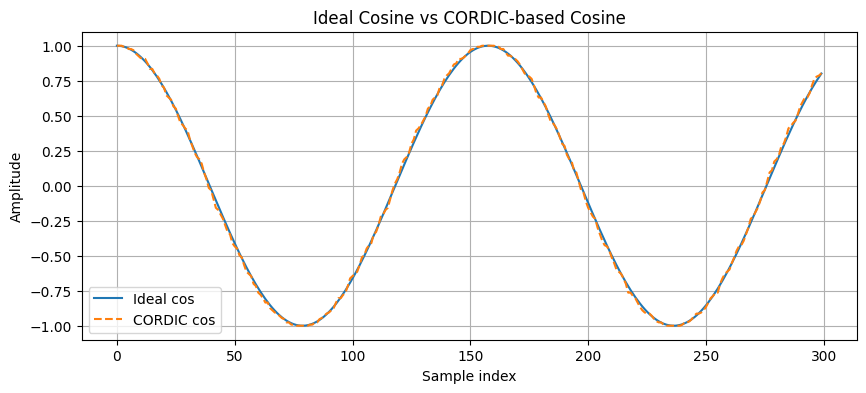

In [33]:
# =========================
# Ve so sanh cos ideal va cos CORDIC
#
# Muc dich:
# So sanh song mang cosine ly tuong
# voi cosine tao bang CORDIC.
#
# Cell nay dung cho phan:
# CORDIC-based carrier generator
# =========================

plt.figure(figsize=(10, 4))
plt.plot(cos_ideal[:300], label="Ideal cos")
plt.plot(cos_cordic[:300], "--", label="CORDIC cos")

plt.title("Ideal Cosine vs CORDIC-based Cosine")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.savefig("cordic_cosine_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

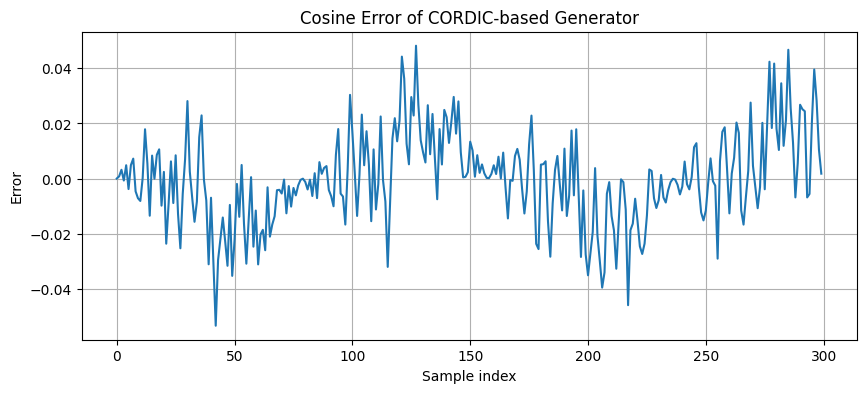

CORDIC carrier EVM = 0.022263866112817197
CORDIC carrier EVM (%) = 2.2263866112817197


In [34]:
# =========================
# Sai so CORDIC so voi ideal
#
# Muc dich:
# Danh gia sai so cua CORDIC-based sin/cos generator
# so voi sin/cos ly tuong.
#
# Cell nay dung cho phan:
# CORDIC carrier error / CORDIC carrier EVM
# =========================

# Sai so giua CORDIC va ideal
cos_error_cordic = cos_cordic - cos_ideal
sin_error_cordic = sin_cordic - sin_ideal

# Ve sai so cosine cua CORDIC
plt.figure(figsize=(10, 4))
plt.plot(cos_error_cordic[:300])

plt.title("Cosine Error of CORDIC-based Generator")
plt.xlabel("Sample index")
plt.ylabel("Error")
plt.grid(True)

plt.savefig("cordic_cosine_error.png", dpi=300, bbox_inches="tight")
plt.show()

# Tinh EVM cua carrier CORDIC
cordic_evm = np.sqrt(
    np.mean(cos_error_cordic**2 + sin_error_cordic**2)
    / np.mean(cos_ideal**2 + sin_ideal**2)
)

print("CORDIC carrier EVM =", cordic_evm)
print("CORDIC carrier EVM (%) =", cordic_evm * 100)

In [35]:
# =========================
# CORDIC EVM theo so iterations
#
# Muc dich:
# Danh gia anh huong cua so vong lap CORDIC
# den do chinh xac cua bo tao song mang sin/cos.
#
# iterations cang lon -> CORDIC xoay vector chinh xac hon
# -> carrier EVM thuong giam
# =========================

iterations_list = [4, 5, 6, 7, 8, 10, 12, 14, 16]

# Giu word_length = 16 de tap trung danh gia anh huong cua iterations
cordic_word_length = 16

cordic_evm_iterations = []

for it in iterations_list:
    # Tao sin/cos bang CORDIC voi so iterations hien tai
    cos_cordic_tmp, sin_cordic_tmp = cordic_sincos_from_phase(
        phase,
        iterations=it,
        word_length=cordic_word_length
    )

    # Tinh sai so so voi sin/cos ly tuong
    err_cos = cos_cordic_tmp - cos_ideal
    err_sin = sin_cordic_tmp - sin_ideal

    # Tinh EVM cua carrier CORDIC
    evm = np.sqrt(
        np.mean(err_cos**2 + err_sin**2)
        / np.mean(cos_ideal**2 + sin_ideal**2)
    )

    cordic_evm_iterations.append(evm)

    print("Iterations =", it, "| EVM =", evm)

cordic_evm_iterations = np.array(cordic_evm_iterations)


# =========================
# Tao bang ket qua
# =========================

cordic_iterations_table = pd.DataFrame({
    "Iterations": iterations_list,
    "Word length": cordic_word_length,
    "CORDIC carrier EVM": cordic_evm_iterations
})

display(cordic_iterations_table)

Iterations = 4 | EVM = 0.07114302065116222
Iterations = 5 | EVM = 0.03471665605414287
Iterations = 6 | EVM = 0.017951015293183867
Iterations = 7 | EVM = 0.008945448805569228
Iterations = 8 | EVM = 0.004490093548541091
Iterations = 10 | EVM = 0.0011306154096178708
Iterations = 12 | EVM = 0.0003035525047456996
Iterations = 14 | EVM = 0.00012957808399012528
Iterations = 16 | EVM = 0.00011813805076549744


,Iterations,Word length,CORDIC carrier EVM
0,4,16,0.071143
1,5,16,0.034717
2,6,16,0.017951
3,7,16,0.008945
4,8,16,0.004490
5,10,16,0.001131
6,12,16,0.000304
7,14,16,0.000130
8,16,16,0.000118


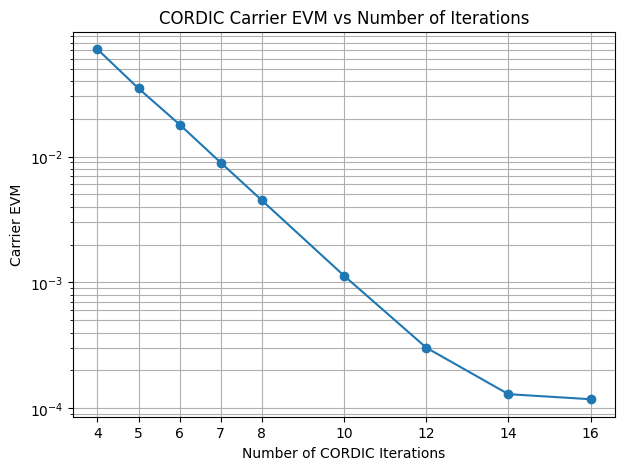

In [36]:
# =========================
# Ve CORDIC EVM theo iterations
#
# Muc dich:
# Quan sat anh huong cua so vong lap CORDIC
# den sai so cua bo tao song mang sin/cos.
#
# iterations cang lon -> do chinh xac cang cao
# -> carrier EVM thuong giam
# =========================

cordic_evm_plot = np.array(cordic_evm_iterations, dtype=float)

# Neu EVM = 0 thi thay bang gia tri nho de ve tren truc log
cordic_evm_plot[cordic_evm_plot == 0] = 1e-12

plt.figure(figsize=(7, 5))
plt.semilogy(iterations_list, cordic_evm_plot, marker='o')

plt.title("CORDIC Carrier EVM vs Number of Iterations")
plt.xlabel("Number of CORDIC Iterations")
plt.ylabel("Carrier EVM")
plt.xticks(iterations_list)
plt.grid(True, which="both")

plt.savefig("cordic_evm_vs_iterations.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# =========================
# Uoc luong tai nguyen CORDIC
#
# Muc dich:
# Uoc luong tai nguyen tinh toan cua CORDIC
# theo so vong lap iterations.
#
# Moi iteration CORDIC gom:
# x update -> 1 add/sub
# y update -> 1 add/sub
# z update -> 1 add/sub
#
# Tong add/sub operations = iterations x 3
#
# CORDIC khong can multiplier,
# chu yeu dung add/sub, shift va bang hang so arctan.
# =========================

cordic_resource_rows = []

for it in iterations_list:
    xy_add_sub = it * 2        # x va y update
    z_add_sub = it             # z angle update
    total_add_sub = it * 3     # x, y, z

    shift_operations = it * 2  # dich bit cho x va y
    atan_constants = it        # so hang so arctan can luu

    cordic_resource_rows.append({
        "Iterations": it,
        "X/Y add-sub": xy_add_sub,
        "Z add-sub": z_add_sub,
        "Total add-sub": total_add_sub,
        "Shift operations": shift_operations,
        "Arctan constants": atan_constants,
        "Multiplier": 0
    })

cordic_resource_table = pd.DataFrame(cordic_resource_rows)

display(cordic_resource_table)

,Iterations,X/Y add-sub,Z add-sub,Total add-sub,Shift operations,Arctan constants,Multiplier
0,4,8,4,12,8,4,0
1,5,10,5,15,10,5,0
2,6,12,6,18,12,6,0
3,7,14,7,21,14,7,0
4,8,16,8,24,16,8,0
5,10,20,10,30,20,10,0
6,12,24,12,36,24,12,0
7,14,28,14,42,28,14,0
8,16,32,16,48,32,16,0


In [38]:
# =========================
# So sanh LUT vs CORDIC theo tham so do chinh xac p
#
# Luu y:
# Voi LUT:
# p = phase width
#
# Voi CORDIC:
# p = number of iterations
#
# Hai tham so nay khong hoan toan tuong duong ve phan cung,
# nhung co the dung de so sanh xu huong EVM khi tang do chinh xac.
# =========================

precision_list = [4, 5, 6, 7, 8, 10, 12]

data_bits_compare = 16
cordic_word_length_compare = 16

lut_evm_compare = []
cordic_evm_compare = []

for p in precision_list:
    # =========================
    # LUT:
    # p la phase width
    # =========================
    cos_lut_tmp, sin_lut_tmp = lut_sincos_from_phase(
        phase,
        phase_bits=p,
        data_bits=data_bits_compare
    )

    err_cos_lut = cos_lut_tmp - cos_ideal
    err_sin_lut = sin_lut_tmp - sin_ideal

    evm_lut = np.sqrt(
        np.mean(err_cos_lut**2 + err_sin_lut**2)
        / np.mean(cos_ideal**2 + sin_ideal**2)
    )

    lut_evm_compare.append(evm_lut)

    # =========================
    # CORDIC:
    # p la so iterations
    # =========================
    cos_cordic_tmp, sin_cordic_tmp = cordic_sincos_from_phase(
        phase,
        iterations=p,
        word_length=cordic_word_length_compare
    )

    err_cos_cordic = cos_cordic_tmp - cos_ideal
    err_sin_cordic = sin_cordic_tmp - sin_ideal

    evm_cordic = np.sqrt(
        np.mean(err_cos_cordic**2 + err_sin_cordic**2)
        / np.mean(cos_ideal**2 + sin_ideal**2)
    )

    cordic_evm_compare.append(evm_cordic)

    print(
        "p =", p,
        "| LUT phase bits =", p,
        "| CORDIC iterations =", p,
        "| LUT EVM =", evm_lut,
        "| CORDIC EVM =", evm_cordic
    )

lut_evm_compare = np.array(lut_evm_compare)
cordic_evm_compare = np.array(cordic_evm_compare)


# =========================
# Tao bang so sanh LUT vs CORDIC
# =========================

lut_cordic_compare_table = pd.DataFrame({
    "p": precision_list,
    "LUT phase bits": precision_list,
    "CORDIC iterations": precision_list,
    "LUT EVM": lut_evm_compare,
    "CORDIC EVM": cordic_evm_compare
})

display(lut_cordic_compare_table)

p = 4 | LUT phase bits = 4 | CORDIC iterations = 4 | LUT EVM = 0.2245357500035352 | CORDIC EVM = 0.07114302065116222
p = 5 | LUT phase bits = 5 | CORDIC iterations = 5 | LUT EVM = 0.11192685313363752 | CORDIC EVM = 0.03471665605414287
p = 6 | LUT phase bits = 6 | CORDIC iterations = 6 | LUT EVM = 0.05533801823151576 | CORDIC EVM = 0.017951015293183867
p = 7 | LUT phase bits = 7 | CORDIC iterations = 7 | LUT EVM = 0.02702878741107333 | CORDIC EVM = 0.008945448805569228
p = 8 | LUT phase bits = 8 | CORDIC iterations = 8 | LUT EVM = 0.012868369219168835 | CORDIC EVM = 0.004490093548541091
p = 10 | LUT phase bits = 10 | CORDIC iterations = 10 | LUT EVM = 0.0022196933690157594 | CORDIC EVM = 0.0011306154096178708
p = 12 | LUT phase bits = 12 | CORDIC iterations = 12 | LUT EVM = 0.00016674701707713901 | CORDIC EVM = 0.0003035525047456996


,p,LUT phase bits,CORDIC iterations,LUT EVM,CORDIC EVM
0,4,4,4,0.224536,0.071143
1,5,5,5,0.111927,0.034717
2,6,6,6,0.055338,0.017951
3,7,7,7,0.027029,0.008945
4,8,8,8,0.012868,0.004490
5,10,10,10,0.002220,0.001131
6,12,12,12,0.000167,0.000304


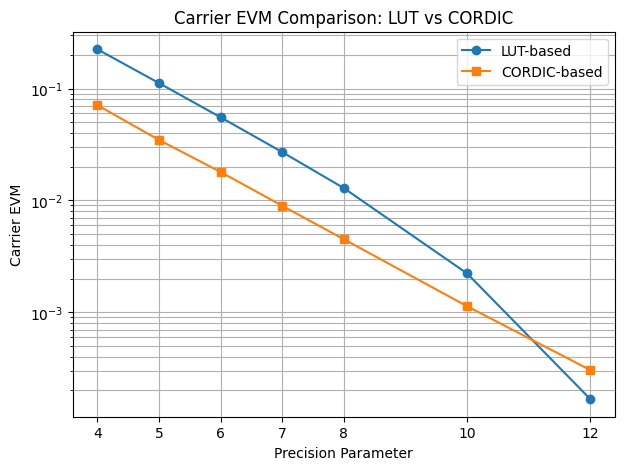

In [39]:
# =========================
# Ve so sanh EVM LUT vs CORDIC
#
# Muc dich:
# So sanh sai so carrier EVM giua LUT-based generator
# va CORDIC-based generator.
#
# Luu y:
# Voi LUT:
# Precision Parameter = phase width
#
# Voi CORDIC:
# Precision Parameter = number of iterations
# =========================

lut_evm_compare_plot = np.array(lut_evm_compare, dtype=float)
cordic_evm_compare_plot = np.array(cordic_evm_compare, dtype=float)

# Neu EVM = 0 thi thay bang gia tri nho de ve tren truc log
lut_evm_compare_plot[lut_evm_compare_plot == 0] = 1e-12
cordic_evm_compare_plot[cordic_evm_compare_plot == 0] = 1e-12

plt.figure(figsize=(7, 5))

plt.semilogy(
    precision_list,
    lut_evm_compare_plot,
    marker='o',
    label="LUT-based"
)

plt.semilogy(
    precision_list,
    cordic_evm_compare_plot,
    marker='s',
    label="CORDIC-based"
)

plt.title("Carrier EVM Comparison: LUT vs CORDIC")
plt.xlabel("Precision Parameter")
plt.ylabel("Carrier EVM")
plt.xticks(precision_list)
plt.grid(True, which="both")
plt.legend()

plt.savefig("carrier_evm_lut_vs_cordic.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# =========================
# Uoc luong resource usage LUT vs CORDIC
#
# Muc dich:
# So sanh tai nguyen cua LUT-based va CORDIC-based carrier generator.
#
# Luu y:
# Voi LUT:
# p = phase width
#
# Voi CORDIC:
# p = number of iterations
#
# Hai tham so nay khong hoan toan tuong duong,
# nhung co the dung de so sanh xu huong resource.
# =========================

resource_compare_rows = []

for p in precision_list:
    # =========================
    # LUT resource
    # =========================
    lut_entries = 2 ** p

    # Luu ca sin va cos, moi gia tri data_bits_compare bit
    lut_memory_bits = lut_entries * data_bits_compare * 2
    lut_memory_bytes = lut_memory_bits / 8
    lut_memory_kbytes = lut_memory_bytes / 1024

    # =========================
    # CORDIC resource
    # =========================
    xy_add_sub = p * 2          # x update va y update
    z_add_sub = p               # z angle update
    total_add_sub = p * 3       # x, y, z

    shift_operations = p * 2    # shift cho x va y
    cordic_constants = p        # arctan constants

    resource_compare_rows.append({
        "p": p,
        "LUT entries": lut_entries,
        "LUT memory bits": lut_memory_bits,
        "LUT memory bytes": lut_memory_bytes,
        "LUT memory KB": lut_memory_kbytes,
        "CORDIC X/Y add-sub": xy_add_sub,
        "CORDIC Z add-sub": z_add_sub,
        "CORDIC total add-sub": total_add_sub,
        "CORDIC shift operations": shift_operations,
        "CORDIC constants": cordic_constants,
        "CORDIC multipliers": 0
    })

resource_compare_table = pd.DataFrame(resource_compare_rows)

display(resource_compare_table)

,p,LUT entries,LUT memory bits,LUT memory bytes,LUT memory KB,CORDIC X/Y add-sub,CORDIC Z add-sub,CORDIC total add-sub,CORDIC shift operations,CORDIC constants,CORDIC multipliers
0,4,16,512,64.0,0.0625,8,4,12,8,4,0
1,5,32,1024,128.0,0.1250,10,5,15,10,5,0
2,6,64,2048,256.0,0.2500,12,6,18,12,6,0
3,7,128,4096,512.0,0.5000,14,7,21,14,7,0
4,8,256,8192,1024.0,1.0000,16,8,24,16,8,0
5,10,1024,32768,4096.0,4.0000,20,10,30,20,10,0
6,12,4096,131072,16384.0,16.0000,24,12,36,24,12,0


In [41]:
# =========================
# QAM modulation output using ideal, LUT, and CORDIC carriers
#
# Muc dich:
# So sanh tin hieu QAM sau dieu che khi dung:
# 1. Carrier ly tuong
# 2. Carrier tao bang LUT
# 3. Carrier tao bang CORDIC
#
# Cong thuc QAM modulation:
# s(t) = I(t)*cos(wt) - Q(t)*sin(wt)
#
# Cong thuc nay giong voi Verilog RTL:
# qam_out = I*cos - Q*sin
# =========================

num_qam_samples = len(symbols_norm)

# Lay thanh phan I va Q tu symbol 16-QAM da chuan hoa
I_qam = np.real(symbols_norm)
Q_qam = np.imag(symbols_norm)

# Tao phase cho song mang
n_qam = np.arange(num_qam_samples)
carrier_cycles_qam = 13

phase_qam = 2 * np.pi * carrier_cycles_qam * n_qam / num_qam_samples

# =========================
# Carrier ly tuong
# =========================

cos_ideal_qam = np.cos(phase_qam)
sin_ideal_qam = np.sin(phase_qam)

# =========================
# Carrier tao bang LUT
# =========================

cos_lut_qam, sin_lut_qam = lut_sincos_from_phase(
    phase_qam,
    phase_bits=8,
    data_bits=12
)

# =========================
# Carrier tao bang CORDIC
# =========================

cos_cordic_qam, sin_cordic_qam = cordic_sincos_from_phase(
    phase_qam,
    iterations=12,
    word_length=16
)

# =========================
# QAM modulation output
# s = I*cos - Q*sin
# =========================

s_ideal = I_qam * cos_ideal_qam - Q_qam * sin_ideal_qam
s_lut = I_qam * cos_lut_qam - Q_qam * sin_lut_qam
s_cordic = I_qam * cos_cordic_qam - Q_qam * sin_cordic_qam

# =========================
# Tinh EVM cua output QAM
# =========================

evm_qam_lut = np.sqrt(
    np.mean((s_lut - s_ideal) ** 2)
    / np.mean(s_ideal ** 2)
)

evm_qam_cordic = np.sqrt(
    np.mean((s_cordic - s_ideal) ** 2)
    / np.mean(s_ideal ** 2)
)

print("QAM output EVM using LUT carrier =", evm_qam_lut)
print("QAM output EVM using CORDIC carrier =", evm_qam_cordic)

print("QAM output EVM using LUT carrier (%) =", evm_qam_lut * 100)
print("QAM output EVM using CORDIC carrier (%) =", evm_qam_cordic * 100)


# =========================
# Tao bang ket qua de dua vao bao cao
# =========================

qam_output_evm_table = pd.DataFrame({
    "Carrier method": [
        "LUT-based carrier",
        "CORDIC-based carrier"
    ],
    "QAM output EVM": [
        evm_qam_lut,
        evm_qam_cordic
    ],
    "QAM output EVM (%)": [
        evm_qam_lut * 100,
        evm_qam_cordic * 100
    ]
})

display(qam_output_evm_table)

QAM output EVM using LUT carrier = 0.014145988388915263
QAM output EVM using CORDIC carrier = 0.00029781708418290725
QAM output EVM using LUT carrier (%) = 1.4145988388915263
QAM output EVM using CORDIC carrier (%) = 0.029781708418290725


,Carrier method,QAM output EVM,QAM output EVM (%)
0,LUT-based carrier,0.014146,1.414599
1,CORDIC-based carrier,0.000298,0.029782


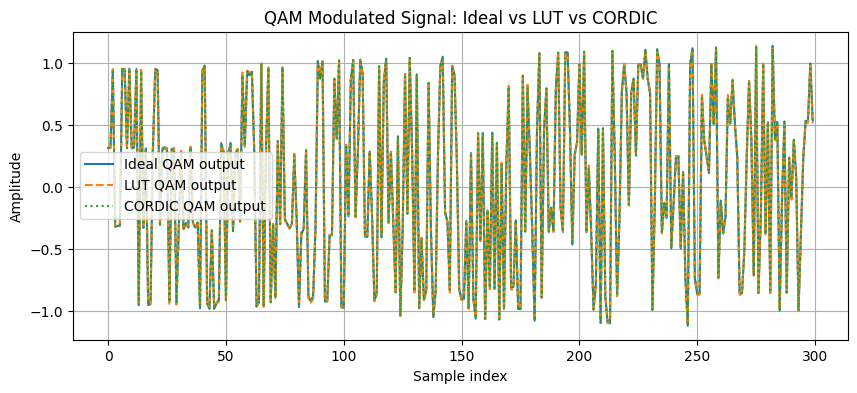

In [42]:
# =========================
# Ve mot doan tin hieu QAM output
#
# Muc dich:
# So sanh tin hieu QAM sau dieu che khi dung:
# 1. Ideal carrier
# 2. LUT-based carrier
# 3. CORDIC-based carrier
#
# Cell nay dung cho phan:
# QAM modulation output comparison
# =========================

num_plot = min(300, len(s_ideal))

plt.figure(figsize=(10, 4))

plt.plot(s_ideal[:num_plot], label="Ideal QAM output")
plt.plot(s_lut[:num_plot], "--", label="LUT QAM output")
plt.plot(s_cordic[:num_plot], ":", label="CORDIC QAM output")

plt.title("QAM Modulated Signal: Ideal vs LUT vs CORDIC")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.savefig("qam_output_ideal_lut_cordic.png", dpi=300, bbox_inches="tight")
plt.show()

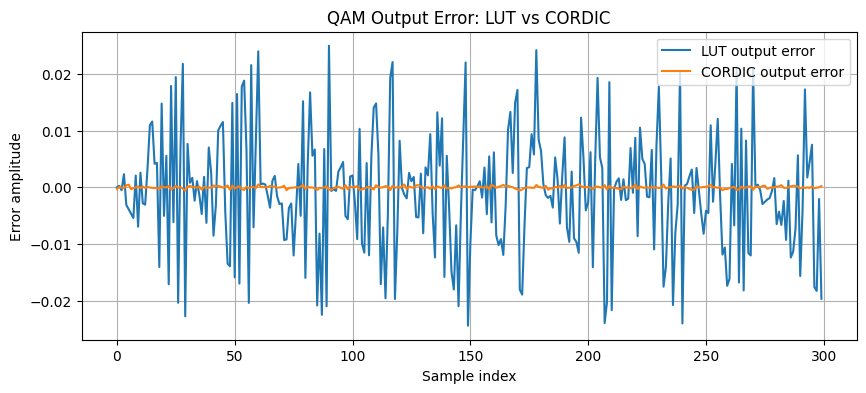

QAM output EVM using LUT carrier = 0.014145988388915263
QAM output EVM using CORDIC carrier = 0.00029781708418290725
QAM output EVM using LUT carrier (%) = 1.4145988388915263
QAM output EVM using CORDIC carrier (%) = 0.029781708418290725


,Method,QAM output EVM,QAM output EVM (%)
0,LUT-based carrier,0.014146,1.414599
1,CORDIC-based carrier,0.000298,0.029782


In [43]:
# =========================
# Sai so QAM output: LUT/CORDIC so voi ideal
#
# Muc dich:
# So sanh sai so cua tin hieu QAM output
# khi dung LUT carrier va CORDIC carrier
# so voi ideal carrier.
#
# Cell nay dung cho phan:
# QAM output error comparison
# =========================

error_qam_lut = s_lut - s_ideal
error_qam_cordic = s_cordic - s_ideal

num_plot = min(300, len(s_ideal))

plt.figure(figsize=(10, 4))

plt.plot(
    error_qam_lut[:num_plot],
    label="LUT output error"
)

plt.plot(
    error_qam_cordic[:num_plot],
    label="CORDIC output error"
)

plt.title("QAM Output Error: LUT vs CORDIC")
plt.xlabel("Sample index")
plt.ylabel("Error amplitude")
plt.grid(True)
plt.legend()

plt.savefig("qam_output_error_lut_vs_cordic.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# In ket qua EVM
# =========================

print("QAM output EVM using LUT carrier =", evm_qam_lut)
print("QAM output EVM using CORDIC carrier =", evm_qam_cordic)

print("QAM output EVM using LUT carrier (%) =", evm_qam_lut * 100)
print("QAM output EVM using CORDIC carrier (%) =", evm_qam_cordic * 100)


# =========================
# Bang ket qua EVM output QAM
# =========================

qam_output_error_table = pd.DataFrame({
    "Method": [
        "LUT-based carrier",
        "CORDIC-based carrier"
    ],
    "QAM output EVM": [
        evm_qam_lut,
        evm_qam_cordic
    ],
    "QAM output EVM (%)": [
        evm_qam_lut * 100,
        evm_qam_cordic * 100
    ]
})

display(qam_output_error_table)

QAM output EVM using LUT (4-bit) = 0.22563499356919656
QAM output EVM using LUT (4-bit) (%) = 22.563499356919657

QAM output EVM using CORDIC (12-iter, 16-bit) = 0.02237452228290742
QAM output EVM using CORDIC (12-iter, 16-bit) (%) = 2.237452228290742


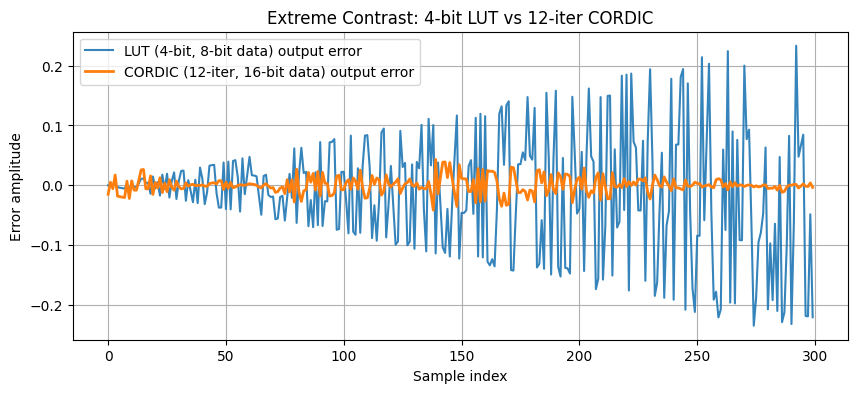

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# QAM modulation output using ideal, LUT (4-bit), and CORDIC (8-iter)
#
# Cấu hình thực tế theo Verilog:
# - LUT: 4-bit phase, 8-bit data
# - CORDIC: 10-bit phase (ẩn trong phase_qam), 8 iterations, 8-bit data
# =========================

num_qam_samples = len(symbols_norm)
I_qam = np.real(symbols_norm)
Q_qam = np.imag(symbols_norm)

n_qam = np.arange(num_qam_samples)
carrier_cycles_qam = 13
phase_qam = 2 * np.pi * carrier_cycles_qam * n_qam / num_qam_samples

# 1. Carrier lý tưởng
cos_ideal_qam = np.cos(phase_qam)
sin_ideal_qam = np.sin(phase_qam)

# 2. Carrier LUT (Cấu hình Verilog cũ)
# THAY ĐỔI: phase_bits=4 (16 điểm), data_bits=8 (biên độ max 127)
cos_lut_qam, sin_lut_qam = lut_sincos_from_phase(
    phase_qam,
    phase_bits=4,
    data_bits=8
)

# 3. Carrier CORDIC (Cấu hình Python gốc)
# THAY ĐỔI: iterations=12 (12 vòng lặp), word_length=16 (đầu ra 16-bit)
cos_cordic_qam, sin_cordic_qam = cordic_sincos_from_phase(
    phase_qam,
    iterations=8,
    word_length=8
)

# =========================
# Điều chế QAM
# =========================
s_ideal = I_qam * cos_ideal_qam - Q_qam * sin_ideal_qam
s_lut = I_qam * cos_lut_qam - Q_qam * sin_lut_qam
s_cordic = I_qam * cos_cordic_qam - Q_qam * sin_cordic_qam

# =========================
# Tính EVM
# =========================
evm_qam_lut = np.sqrt(np.mean((s_lut - s_ideal)**2) / np.mean(s_ideal**2))
evm_qam_cordic = np.sqrt(np.mean((s_cordic - s_ideal)**2) / np.mean(s_ideal**2))

print("QAM output EVM using LUT (4-bit) =", evm_qam_lut)
print("QAM output EVM using LUT (4-bit) (%) =", evm_qam_lut * 100)

print("\nQAM output EVM using CORDIC (12-iter, 16-bit) =", evm_qam_cordic)
print("QAM output EVM using CORDIC (12-iter, 16-bit) (%) =", evm_qam_cordic * 100)

# =========================
# Vẽ biểu đồ Sai số
# =========================
error_qam_lut = s_lut - s_ideal
error_qam_cordic = s_cordic - s_ideal

num_plot = min(300, len(s_ideal))

plt.figure(figsize=(10, 4))
plt.plot(error_qam_lut[:num_plot], label="LUT (4-bit, 8-bit data) output error", alpha=0.9)
plt.plot(error_qam_cordic[:num_plot], label="CORDIC (12-iter, 16-bit data) output error", linewidth=2)

plt.title("Extreme Contrast: 4-bit LUT vs 12-iter CORDIC")
plt.xlabel("Sample index")
plt.ylabel("Error amplitude")
plt.grid(True)
plt.legend()
plt.show()

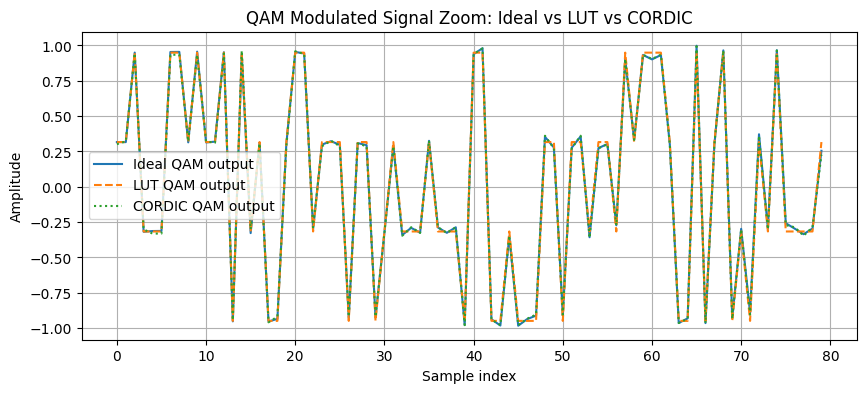

In [45]:
# =========================
# Ve zoom QAM output cho de nhin
#
# Muc dich:
# Phong to mot doan ngan cua tin hieu QAM output
# de thay ro su khac nhau giua:
# Ideal, LUT va CORDIC.
#
# Cell nay dung cho phan:
# QAM output comparison
# =========================

num_zoom = min(80, len(s_ideal))

plt.figure(figsize=(10, 4))

plt.plot(s_ideal[:num_zoom], label="Ideal QAM output")
plt.plot(s_lut[:num_zoom], "--", label="LUT QAM output")
plt.plot(s_cordic[:num_zoom], ":", label="CORDIC QAM output")

plt.title("QAM Modulated Signal Zoom: Ideal vs LUT vs CORDIC")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.savefig("qam_output_zoom_ideal_lut_cordic.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# =========================
# Tong hop EVM cua QAM output
#
# Muc dich:
# Tong ket sai so QAM output khi dung:
# 1. LUT-based carrier
# 2. CORDIC-based carrier
#
# EVM cang nho -> QAM output cang gan voi ideal output
# =========================

print("===== QAM Output EVM Summary =====")

print("LUT-based QAM output EVM     =", evm_qam_lut)
print("CORDIC-based QAM output EVM  =", evm_qam_cordic)

print("LUT-based QAM output EVM (%)    =", evm_qam_lut * 100)
print("CORDIC-based QAM output EVM (%) =", evm_qam_cordic * 100)


# =========================
# Tao bang tong hop EVM
# =========================

qam_evm_summary_table = pd.DataFrame({
    "Method": [
        "LUT-based carrier",
        "CORDIC-based carrier"
    ],
    "QAM output EVM": [
        evm_qam_lut,
        evm_qam_cordic
    ],
    "QAM output EVM (%)": [
        evm_qam_lut * 100,
        evm_qam_cordic * 100
    ]
})

display(qam_evm_summary_table)


# =========================
# Nhan xet ket qua
# =========================

tolerance = 1e-12

if np.isclose(evm_qam_lut, evm_qam_cordic, atol=tolerance):
    print("Nhan xet: LUT va CORDIC co sai so gan nhu tuong duong trong cau hinh hien tai.")
elif evm_qam_lut > evm_qam_cordic:
    print("Nhan xet: CORDIC co sai so nho hon LUT trong cau hinh hien tai.")
else:
    print("Nhan xet: LUT co sai so nho hon CORDIC trong cau hinh hien tai.")

===== QAM Output EVM Summary =====
LUT-based QAM output EVM     = 0.22563499356919656
CORDIC-based QAM output EVM  = 0.02237452228290742
LUT-based QAM output EVM (%)    = 22.563499356919657
CORDIC-based QAM output EVM (%) = 2.237452228290742


,Method,QAM output EVM,QAM output EVM (%)
0,LUT-based carrier,0.225635,22.563499
1,CORDIC-based carrier,0.022375,2.237452


Nhan xet: CORDIC co sai so nho hon LUT trong cau hinh hien tai.


In [47]:
# =========================
# Bang so sanh resource usage uoc luong
#
# Muc dich:
# Tong hop tai nguyen uoc luong cua LUT va CORDIC
# de dua vao bao cao.
#
# Voi LUT:
# p = phase width
#
# Voi CORDIC:
# p = number of iterations
#
# Luu y:
# CORDIC moi iteration co:
# x update -> 1 add/sub
# y update -> 1 add/sub
# z update -> 1 add/sub
#
# Nen tong add/sub = p * 3
# =========================

precision_list = [4, 5, 6, 7, 8, 10, 12]
data_bits_compare = 16

resource_summary_rows = []

for p in precision_list:
    # =========================
    # LUT resource
    # =========================
    lut_entries = 2 ** p

    # Luu ca sin va cos
    lut_memory_bits = lut_entries * data_bits_compare * 2
    lut_memory_bytes = lut_memory_bits / 8
    lut_memory_kbytes = lut_memory_bytes / 1024

    # =========================
    # CORDIC resource
    # =========================
    cordic_xy_add_sub = p * 2
    cordic_z_add_sub = p
    cordic_total_add_sub = p * 3
    cordic_shift_operations = p * 2
    cordic_constants = p

    resource_summary_rows.append({
        "Precision p": p,
        "LUT entries": lut_entries,
        "LUT memory bits": lut_memory_bits,
        "LUT memory bytes": lut_memory_bytes,
        "LUT memory KB": lut_memory_kbytes,
        "CORDIC X/Y add-sub": cordic_xy_add_sub,
        "CORDIC Z add-sub": cordic_z_add_sub,
        "CORDIC total add-sub": cordic_total_add_sub,
        "CORDIC shift operations": cordic_shift_operations,
        "CORDIC constants": cordic_constants,
        "CORDIC multipliers": 0
    })

resource_summary_table = pd.DataFrame(resource_summary_rows)

display(resource_summary_table)

,Precision p,LUT entries,LUT memory bits,LUT memory bytes,LUT memory KB,CORDIC X/Y add-sub,CORDIC Z add-sub,CORDIC total add-sub,CORDIC shift operations,CORDIC constants,CORDIC multipliers
0,4,16,512,64.0,0.0625,8,4,12,8,4,0
1,5,32,1024,128.0,0.1250,10,5,15,10,5,0
2,6,64,2048,256.0,0.2500,12,6,18,12,6,0
3,7,128,4096,512.0,0.5000,14,7,21,14,7,0
4,8,256,8192,1024.0,1.0000,16,8,24,16,8,0
5,10,1024,32768,4096.0,4.0000,20,10,30,20,10,0
6,12,4096,131072,16384.0,16.0000,24,12,36,24,12,0
